In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vT3B8kxssAwo-4BA27WHbRQm8ExK8SGGOSWxrH1Hq69CbysHHcBCvafAh28wacMdFLhBrfXICUFyK_g/pub?output=csv')

## Часть 1 чистка данных
*garbage in - garbage out*

In [ ]:
data.head()

,Unnamed: 0,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time
0,0,96422511,female,68,android,89656828,передачи о новых технологиях,show,share,6,playlist,0
1,1,45247030,male,62,android_tv,89784877,автопрому новости,news,search,0,NaN,0
2,2,79572413,male,12,web,10555855,логистическое законодательство,news,search,0,NaN,0
3,3,821317,female,58,android_tv,72054848,банковские премии новости,news,search,0,NaN,0
4,4,6206023,female,24,android,20838049,вики шоу аманда,show,subscribe,7,author,0


In [ ]:
## видим, что создался ненужный столбец 'Unnamed: 0', дропнем его
data.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
data.isna().sum() ## все столбцы хорошие(не имеют пропусков), кроме doc_type

,0
user_id,0
sex,0
age,0
platform,0
query_id,0
query_text,0
query_type,0
event,0
click_position,0
doc_type,4958


In [ ]:
null_values = data[data['doc_type'].isna()]
((null_values['click_position'] == 0) & (null_values['event'] == 'search')).sum() / len(null_values), \
((data['click_position'] == 0) & (data['event'] == 'search')).sum() / len(null_values), \
(data['event'] == 'search').sum() / len(null_values)
## видим, что все пропущенные значения образовались там, где click_position равен нулю и event - 'search'(причем в обратную сторону тоже работает)
## скорее всего, это получилось из-за того, что человек, у которого были такие параметры, вообще ничего не открывал и не делал никаких целевых действий

(np.float64(1.0), np.float64(1.0), np.float64(1.0))

In [ ]:
data.fillna('no_data', inplace=True) ## заменим пропуски на "no_data"

In [ ]:
data['click_position'].max() ## интересно, что максимальное значение позиции документа в выдаче поиска - 30

30

In [ ]:
len(null_values) / len(data[(data['click_position'] == 0)]) ## видно, что остались необработанные случаи
## (где click_position равен нулю, а doc_type определен)
## ## скорее всего, эти значения получились, когда значение позиции документа в выдаче поиска было более 30
## Тогда заменим такие значения на большее число, например 31

0.9391930289827619

In [ ]:
data.loc[(data['click_position'] == 0) & (data['event'] != 'search'),'click_position']= 31 ## заменили значения

In [ ]:
data.describe() ## видим сразу, что самый минимальный возраст равен нулю
## так же странно, что 75-ый перцентиль по view_time равен 0, т.е более 75% данных нулевые

,user_id,age,query_id,click_position,view_time
count,2.000000e+04,20000.000000,2.000000e+04,20000.000000,20000.000000
mean,4.940472e+07,30.029600,1.629075e+08,6.713700,614.775450
std,2.896590e+07,22.588294,2.443505e+08,7.057898,2217.290922
min,1.273000e+03,0.000000,8.758000e+03,0.000000,0.000000
25%,2.405560e+07,11.000000,3.215079e+07,1.000000,0.000000
50%,4.946180e+07,30.000000,6.425107e+07,5.000000,0.000000
75%,7.429182e+07,50.000000,9.664634e+07,10.000000,0.000000
max,9.999570e+07,69.000000,9.998612e+08,31.000000,17994.000000


In [ ]:
zero_age = data[data['age'] == 0]
no_zero_age = data[data['age'] != 0]

(zero_age['sex'] == 'anonym').sum() / len(zero_age) ## более 94% людей с нулевым возрастом были анонимами

np.float64(0.946334248890767)

In [ ]:
len(no_zero_age[no_zero_age['age'] < 10]) ## видим, что нет людей с возрастом меньше 10 лет, поэтому явно age = 0 -
## выбросы(скорее всего не было данных по этим людям, т.к более 94% - анонимы)

0

In [ ]:
data.loc[data['age'] == 0, 'age'] = no_zero_age['age'].median() ## заменим значения с нулевым возрастом на медиану
## по людям с ненулевым возрастом(более устойчива к выбросам)
data.head()

,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time
0,96422511,female,68,android,89656828,передачи о новых технологиях,show,share,6,playlist,0
1,45247030,male,62,android_tv,89784877,автопрому новости,news,search,0,no_data,0
2,79572413,male,12,web,10555855,логистическое законодательство,news,search,0,no_data,0
3,821317,female,58,android_tv,72054848,банковские премии новости,news,search,0,no_data,0
4,6206023,female,24,android,20838049,вики шоу аманда,show,subscribe,7,author,0


In [ ]:
data_user = data['user_id'].value_counts()
user_not_uniq = pd.DataFrame(data_user[data_user > 1])
user_not_uniq.reset_index(inplace=True)
data_not_uniq = data.merge(user_not_uniq, on='user_id')
data_not_uniq[data_not_uniq['user_id'] == 46055223]

,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time,count
3,46055223,female,30,android,93486615,как играть на бас-гитаре,music,tap,9,video,0,4
1782,46055223,anonym,39,smart_tv,310901589,стоимость производства 'Мстителей',films,like,1,video,0,4
4317,46055223,female,43,android_tv,49866004,телевизионные технологии новости,news,like,13,author,0,4
6415,46055223,female,30,android,93486615,большое шоу 9 сезон,show,subscribe,14,author,0,4


In [ ]:
data_not_uniq['is_male'] = (data_not_uniq['sex'] == 'male').astype('int')
data_not_uniq['is_female'] = (data_not_uniq['sex'] == 'female').astype('int')

data_sex = data_not_uniq.groupby(['user_id'], as_index=False).agg({'is_male': 'sum', 'is_female': 'sum'})
data_sex

,user_id,is_male,is_female
0,34723,1,0
1,70859,1,1
2,76099,1,1
3,84809,0,2
4,87246,2,0
...,...,...,...
3141,99896130,0,2
3142,99926914,1,1
3143,99945401,0,0
3144,99948314,0,2


In [ ]:
bad_id = data_sex[((data_sex['is_male'] > 0) & (data_sex['is_female'] > 0))]
bad_id
## довольно странно, что есть 471 id, которые поменяли пол(норм, когда меняют пол с anonim на male,
## но не когда с female на male). Я бы не исопользовал эти id
## Т.к других данных мало, и человек может спокойно менять возраст и платформу, то проверку валидности user_id будем осуществлять таким образом

,user_id,is_male,is_female
1,70859,1,1
2,76099,1,1
9,276713,2,1
15,364865,1,1
20,446706,1,1
...,...,...,...
3112,99059968,1,1
3125,99454609,1,1
3129,99575371,1,1
3136,99752920,1,1


In [ ]:
data_clean = data.merge(bad_id, how='outer', indicator=True)
## сделаем outer join и возьмем значения, где _merge принимает значения left_only)
data_clean = data_clean[data_clean['_merge'] == 'left_only']
data_clean = data_clean.iloc[:, :-3] ## дропнем последние 3 колонки, так как там везде NaN
data_clean

,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time
0,1273,female,34,iphone,21406010,шоу из шоу олеся иванченко,show,tap,8,video,0
1,10462,male,10,android,73161897,Дима Маслиников шоу кто лудше гатовит,show,share,8,video,0
2,16177,anonym,39,smart_tv,362890087,где смотреть старые фильмы легально,films,tap,2,video,0
3,16551,female,34,web,6996343,совпадения в киновселенных,films,tap,1,video,0
4,23006,anonym,39,android_tv,56040658,страхование жизни новости,news,tap,12,video,0
...,...,...,...,...,...,...,...,...,...,...,...
19995,99955241,male,43,android,271992484,русские фильмы про войну,films,search,0,no_data,0
19996,99974115,female,28,iphone,46091076,маркетинговые кампании новости,news,share,18,author,0
19997,99994451,female,30,smart_tv,540699841,лучшие диалоги в истории кино,films,like,2,video,0
19998,99994735,female,21,web,90886738,рисковые технологии новости,news,like,18,video,0


In [ ]:
##
data_query = data_clean['query_id'].value_counts()
not_uniq = data_query[data_query > 1] ## значения query_id, которые повторяются
not_uniq = pd.DataFrame(not_uniq).rename(columns={'count': 'query_count'})

not_uniq.reset_index(inplace=True)
not_uniq['query_count'].value_counts() ## есть 1339 данных с 'query_id', которые повторяются два раза, и 63 данных, которые повторяются 3 раза

,count
query_count,
2,1339
3,63


In [ ]:
not_uniq_data = data_clean.merge(not_uniq, on='query_id', how='inner')
not_uniq_data[(not_uniq_data['query_count'] == 3) & (not_uniq_data['query_id'] == 22163705)]
## нашел очень странные инсайты: почему-то query_id - не уникальный ключ,
## даже более того - не является ключом(т.к user_id почему-то различается для одинаковых query_id)

,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time,query_count
888,29386283,female,11,web,22163705,промышленные премии новости,news,view,5,clip,300,3
1501,51150028,anonym,39,smart_tv,22163705,программы с хореографическими номерами,show,subscribe,3,author,0,3
1502,51150028,anonym,39,smart_tv,22163705,уроки фортепиано для начинающих,music,subscribe,11,video,0,3


In [ ]:
data_strange = not_uniq_data.groupby(by=['query_id', 'query_count'], as_index=False).agg({'user_id': 'nunique'}).rename(columns={'user_id': 'user_count'})
(data_strange['user_count'] > 1).mean() ## 38 % query_id с user_count > 1 имеют более 1 юзера(неправильные) и есть много данных с query_id > 1
## я бы вообще не использовал query_id

np.float64(0.38088445078459343)

In [ ]:
## поделим датасет на 2 - один с целевыми действиями(tap, like и тд), другой без целевых действий(только поиск)

have_data = data_clean[~((data_clean['click_position'] == 0) & (data_clean['event'] == 'search'))] #с целевыми действиями
no_data = data_clean[(data_clean['click_position'] == 0) & (data_clean['event'] == 'search')] # без целевых действий
no_data

,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time
6,34723,male,40,android,3693564,та самая мелодия из тик тока,music,search,0,no_data,0
7,34723,anonym,39,smart_tv,602127622,"фильмы, запрещенные в разных странах",films,search,0,no_data,0
13,62028,female,22,iphone,20639511,концерты классической музыки,music,search,0,no_data,0
22,84809,female,53,iphone,52395559,женское шоу с дороховым,show,search,0,no_data,0
23,84809,female,53,iphone,52395559,классика для фона,music,search,0,no_data,0
...,...,...,...,...,...,...,...,...,...,...,...
19990,99945401,anonym,39,iphone,66353913,худи шоу звезды,show,search,0,no_data,0
19991,99948314,female,37,iphone,49469400,кстати шоу выпуск,show,search,0,no_data,0
19992,99948314,female,38,android_tv,72062564,права потребителей новости,news,search,0,no_data,0
19995,99955241,male,43,android,271992484,русские фильмы про войну,films,search,0,no_data,0


## Часть 2 EDA

### Выделение плохих поисков
>- Плохим поиском будем считать строку, где event - search(в no_data)
>- Еще как вариант плохой строкой можно считать топ 10% самых плохих по click_position (значит, было плохое ранжирование)

In [ ]:
data_clean['platform'].value_counts() ## распределение почти равномерное

,count
platform,
iphone,4080
smart_tv,4063
android,4022
android_tv,3783
web,2984


In [ ]:
data_clean['query_type'].value_counts() ## всех значений примерно  поровну

,count
query_type,
films,4813
music,4791
show,4749
news,4579


In [ ]:
data_clean['doc_type'].value_counts() ## клипы - самые популярные

,count
doc_type,
clip,4888
no_data,4673
video,4492
author,3194
playlist,1685


Способ 2 через квантили

In [ ]:
quant = have_data['click_position'].quantile(q=0.9)
quant

np.float64(18.0)

In [ ]:
bad_quant = have_data[have_data['click_position'] >= quant]
bad_quant ##значения с плохим click_position

,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time
35,147287,female,68,android,12191548,энергетический кризис новости,news,tap,21,clip,0
36,151478,anonym,39,iphone,52490144,трейдинг премии новости,news,tap,23,playlist,0
42,201328,anonym,39,smart_tv,295337435,научная фантастика 90-х годов,films,tap,31,author,0
43,205862,anonym,39,smart_tv,158301478,японское аниме для взрослых,films,view,31,clip,895
50,232049,male,43,smart_tv,43870362,новости о пенсиях,news,tap,19,clip,0
...,...,...,...,...,...,...,...,...,...,...,...
19944,99704176,male,16,android,4573559,биржевые новости онлайн,news,view,19,clip,749
19976,99873731,female,54,android,10662608,юридическое законодательство,news,tap,22,author,0
19988,99935850,female,41,iphone,8076310,спортивные скандалы,news,like,18,clip,0
19996,99974115,female,28,iphone,46091076,маркетинговые кампании новости,news,share,18,author,0


In [ ]:
bad_quant['sex'].value_counts() ## можно сказать, что женщин больше

,count
sex,
female,841
male,458
anonym,289


In [ ]:
bad_quant['age'].mean(), have_data['age'].mean() ## нет различий

(np.float64(39.3904282115869), np.float64(39.12125675012273))

In [ ]:
bad_quant['query_type'].value_counts() ## большинство - новости

,count
query_type,
news,1184
films,315
music,60
show,29


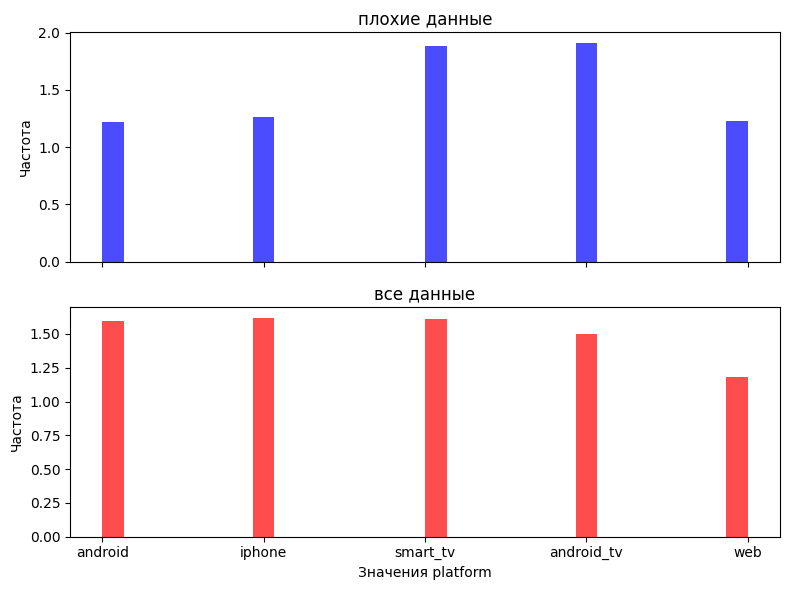

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

# Гистограмма 1
axes[0].hist(bad_quant['platform'], bins=30, color='blue', alpha=0.7, density=True)
axes[0].set_title('плохие данные')
axes[0].set_ylabel('Частота')

# Гистограмма 2
axes[1].hist(data_clean['platform'], bins=30, color='red', alpha=0.7, density=True)
axes[1].set_title('все данные')
axes[1].set_xlabel('Значения platform')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

## вывод - проблемные случаи чаще происходят с телевизорами(мб там сложно печатать)

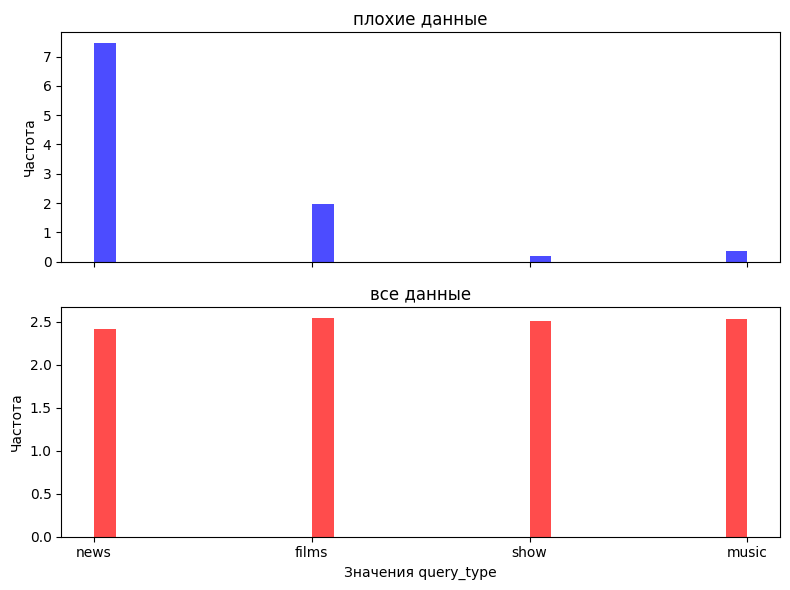

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

# Гистограмма 1
axes[0].hist(bad_quant['query_type'], bins=30, color='blue', alpha=0.7, density=True)
axes[0].set_title('плохие данные')
axes[0].set_ylabel('Частота')

# Гистограмма 2
axes[1].hist(data_clean['query_type'], bins=30, color='red', alpha=0.7, density=True)
axes[1].set_title('все данные')
axes[1].set_xlabel('Значения query_type')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

## вывод - показ новостей чаще приносит проблемные случаи, надо лучше с ними работать

Способ 1 через остутствущие значения

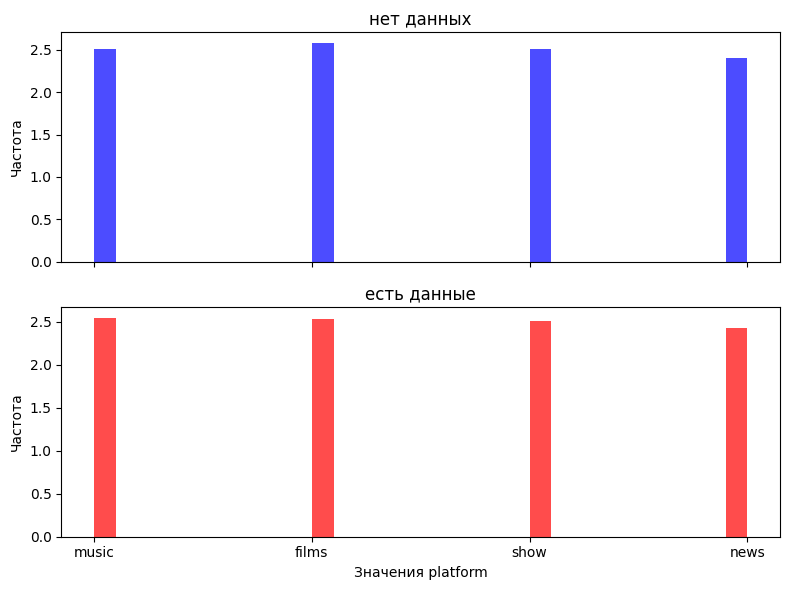

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

# Гистограмма 1
axes[0].hist(no_data['query_type'], bins=30, color='blue', alpha=0.7, density=True)
axes[0].set_title('нет данных')
axes[0].set_ylabel('Частота')

# Гистограмма 2
axes[1].hist(have_data['query_type'], bins=30, color='red', alpha=0.7, density=True)
axes[1].set_title('есть данные')
axes[1].set_xlabel('Значения platform')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

## вывод - различий нет, смотрел на все признаки, они не отличаются